In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [15]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize images (0 to 1)
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Reshape to (28,28,1) for CNN
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [17]:
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

# Clip values to stay between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


In [19]:
input_img = layers.Input(shape=(28, 28, 1))

# ----- Encoder -----
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

# ----- Decoder -----
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Build Model
autoencoder = models.Model(input_img, decoded)

In [20]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 406ms/step - loss: 0.1184 - val_loss: 0.1140
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 396ms/step - loss: 0.1118 - val_loss: 0.1140
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 394ms/step - loss: 0.1121 - val_loss: 0.1140
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 394ms/step - loss: 0.1119 - val_loss: 0.1140
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 395ms/step - loss: 0.1116 - val_loss: 0.1140
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 403ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 402ms/step - loss: 0.1118 - val_loss: 0.1140
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 406ms/step - loss: 0.1122 - val_loss: 0.1140
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 405ms/step - loss: 0.1121 - val_loss: 0.1140
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 186s 396ms/step - loss: 0.1121 - val_loss: 0.1140
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 188s 401ms/step - loss: 0.1119 - val_loss: 0.1140
Epoch 12

In [22]:
decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


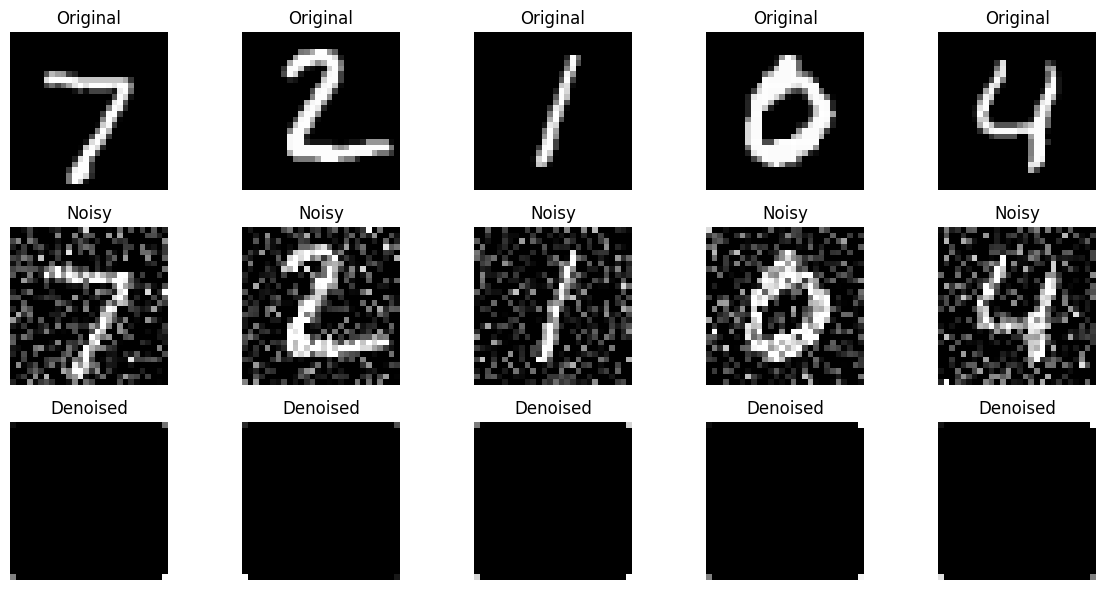

In [23]:
n = 5
plt.figure(figsize=(12,6))

for i in range(n):

    # Original Image
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed Image
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()